# Eksperyment v2 OpenAI: max_chars × overlap × top_k (vision + OpenAI embeddings)

Kopia `experiment_chunk_size_topk_v2.ipynb` z **jedną** zmianą: retrieval używa OpenAI `text-embedding-3-small` zamiast lokalnego `intfloat/multilingual-e5-small`. Cel: sprawdzić, czy komercyjny embedder poprawia recall na 14 pytaniach ewaluacyjnych.

Backend embeddingów jest **lokalny dla notebooka** — osobna kolekcja ChromaDB (`vision_chunks_openai`), `backend/app/retrieval/vision_vector_store.py` nietknięty.

Siatka bez zmian:
- `max_chars ∈ {800, 1500, 2000, 2500, 3000, 3500}`
- `overlap_chars ∈ {0, 200}`
- `top_k ∈ {1, 3, 5, 10, 15}`

Metryki: **page_hit@k**, **fragment_hit@k** (analogicznie do v2).

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import chromadb
import pandas as pd
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction
from dotenv import load_dotenv
from rapidfuzz import fuzz

from backend.app.config import VISION_CACHE_DIR
from backend.app.document.models import (
    DocumentMetadata,
    ExtractedChapter,
    ExtractedDocument,
)
from backend.app.document.vision_chunker import chunk_document

load_dotenv(ROOT / ".env")
assert os.getenv("OPENAI_API_KEY"), "Brak OPENAI_API_KEY w .env — ustaw klucz przed uruchomieniem notebooka."

OPENAI_EMBED_MODEL = "text-embedding-3-small"
EXTRACTION_DIR = VISION_CACHE_DIR
EVAL_PATH = ROOT / "data" / "eval" / "bgk_2024_qa_eval.json"
AVAILABLE_CHAPTERS = sorted(p.stem for p in EXTRACTION_DIR.glob("*.json"))
print("Dostępne rozdziały:", AVAILABLE_CHAPTERS)
print("Embedder:", OPENAI_EMBED_MODEL)

Dostępne rozdziały: ['I', 'II', 'III', 'IV', 'IX', 'V', 'VI', 'VII', 'VIII', 'X']
Embedder: text-embedding-3-small


### 1.1 Lokalny vector store (OpenAI embeddings)

Odpowiedniki `index_vision_chunks` / `search_vision` / `reset_collection` z `vision_vector_store.py`, ale na osobnej kolekcji ChromaDB i `OpenAIEmbeddingFunction`. Funkcje `_format_pages` / `_parse_pages` skopiowane 1:1 — notebook ma być samowystarczalny.

In [3]:
_OAI_COLLECTION = "vision_chunks_openai"
_oai_client = chromadb.Client()
_oai_embed = OpenAIEmbeddingFunction(
    api_key=os.environ["OPENAI_API_KEY"],
    model_name=OPENAI_EMBED_MODEL,
)


def _format_pages(pages: list[int]) -> str:
    if not pages:
        return ""
    pages = sorted(set(pages))
    groups: list[tuple[int, int]] = []
    start = prev = pages[0]
    for p in pages[1:]:
        if p == prev + 1:
            prev = p
            continue
        groups.append((start, prev))
        start = prev = p
    groups.append((start, prev))
    return ",".join(str(a) if a == b else f"{a}-{b}" for a, b in groups)


def _parse_pages(s: str) -> list[int]:
    if not s:
        return []
    out: list[int] = []
    for part in s.split(","):
        part = part.strip()
        if not part:
            continue
        if "-" in part:
            a, b = part.split("-", 1)
            out.extend(range(int(a), int(b) + 1))
        else:
            out.append(int(part))
    return out


def _reset_openai_collection() -> None:
    global _oai_coll
    try:
        _oai_client.delete_collection(_OAI_COLLECTION)
    except Exception:
        pass
    _oai_coll = _oai_client.get_or_create_collection(
        _OAI_COLLECTION, embedding_function=_oai_embed
    )


def _index_openai(chunks: list[dict]) -> None:
    if not chunks:
        return
    _oai_coll.add(
        documents=[c["search_text"] for c in chunks],
        metadatas=[
            {
                "page": c["page"],
                "pages": _format_pages(c["pages"]),
                "chunk_index": c["chunk_index"],
                "chapter": c["chapter"] or "",
                "section": c["section"] or "",
                "element_type": c["element_type"],
                "content": c["content"],
            }
            for c in chunks
        ],
        ids=[f"vp{c['page']}_c{c['chunk_index']}" for c in chunks],
    )


def _search_openai(query: str, top_k: int) -> list[dict]:
    results = _oai_coll.query(query_texts=[query], n_results=top_k)
    output: list[dict] = []
    for i in range(len(results["documents"][0])):
        meta = results["metadatas"][0][i]
        output.append(
            {
                "content": meta["content"],
                "search_text": results["documents"][0][i],
                "page": meta["page"],
                "pages": _parse_pages(meta["pages"]),
                "chapter": meta["chapter"] or None,
                "section": meta["section"] or None,
                "element_type": meta["element_type"],
                "chunk_index": meta["chunk_index"],
                "distance": results["distances"][0][i],
            }
        )
    return output


_reset_openai_collection()
print("Kolekcja gotowa:", _OAI_COLLECTION)

Kolekcja gotowa: vision_chunks_openai


## 2. Load danych (raz, poza pętlą)

Wczytujemy wszystkie rozdziały z cache i pytania ewaluacyjne. `pages` w eval JSON są stringami — konwertujemy do `int`.

In [4]:
def load_full_document() -> ExtractedDocument:
    chapters: list[ExtractedChapter] = []
    for ch_id in AVAILABLE_CHAPTERS:
        chapters.append(ExtractedChapter.load_json(EXTRACTION_DIR / f"{ch_id}.json"))
    total_pages = sum(len(ch.pages) for ch in chapters)
    return ExtractedDocument(
        metadata=DocumentMetadata(
            source_file="raport_2024_pl.pdf",
            total_pages=total_pages,
            extraction_date="notebook",
        ),
        title="BGK 2024 (wszystkie rozdziały z cache)",
        chapters=chapters,
    )


doc = load_full_document()
print(f"Rozdziały: {[ch.chapter_id for ch in doc.chapters]}")
print(f"Łącznie stron: {len(doc.get_all_pages())}")
print(f"Łącznie bloków: {len(doc.get_all_blocks())}")

Rozdziały: ['I', 'II', 'III', 'IV', 'IX', 'V', 'VI', 'VII', 'VIII', 'X']
Łącznie stron: 182
Łącznie bloków: 2242


In [5]:
with open(EVAL_PATH, encoding="utf-8") as f:
    eval_raw = json.load(f)

questions = [
    {
        "id": q["id"],
        "question": q["question"],
        "gt_pages": {int(p) for p in q["pages"]},
        "gt_fragments": list(q["fragment_text"]),
    }
    for q in eval_raw
]
print(f"Pytań: {len(questions)}")
pd.DataFrame(
    [{"id": q["id"], "gt_pages": sorted(q["gt_pages"]), "question": q["question"][:80]} for q in questions]
)

Pytań: 14


,id,gt_pages,question
0,1,[7],Dlaczego część wsparcia BGK nie jest klasyfiko...
1,2,"[9, 112]",Kto został powołany na prezesa Zarządu BGK w 2...
2,3,[10],Jak wygląda struktura Grupy Kapitałowej BGK i ...
3,4,[4],Jaki priorytet dla Polski wskazuje prezes BGK ...
4,5,"[15, 28]",Jaka jest łączna moc instalacji OZE współfinan...
5,6,[40],Jaki jest cel programu Bank Staży?
6,7,[52],W jakiej formie klienci mogą skłądać reklamacje?
7,8,[119],jaka była frekwencja na szkoleniu z obszaru et...
8,9,[126],Co obejmuje I linia obrony w systemie kontroli...
9,10,[133],Jakie są cele polityki kredytowej BGK?


## 3. Grid eksperymentu

In [6]:
MAX_CHARS_GRID = [800, 1500, 2000, 2500, 3000, 3500] # 99999 - całe podrozdziały
OVERLAP_GRID = [0, 200]
TOP_K_GRID = [1, 3, 5, 10, 15]

MAX_TOP_K = max(TOP_K_GRID)

## 4. Funkcje pomocnicze: metryki

- `page_hit(retrieved, gt_pages)` — czy któryś z top_k chunków zawiera którąkolwiek ze stron GT (przecięcie zbiorów `pages`).
- `find_matched_fragment_scored(content, fragments, threshold=85)` — case-insensitive; zwraca `(fragment, score)` dla dokładnego `in` (score=100) lub dla `rapidfuzz.fuzz.partial_ratio ≥ threshold`. Próg 85 akceptuje drobne różnice (literówki OCR, białe znaki, interpunkcja) — zgodnie z zasadą, że "bardzo podobne" fragmenty też są trafieniem.
- `fragment_hit(retrieved, gt_fragments)` — bool wrapper nad `find_matched_fragment_scored` dla któregokolwiek chunku z top_k.

In [7]:
FRAGMENT_MATCH_THRESHOLD = 85.0


def page_hit(retrieved: list[dict], gt_pages: set[int]) -> bool:
    for r in retrieved:
        if set(r["pages"]) & gt_pages:
            return True
    return False


def find_matched_fragment_scored(
    content: str,
    fragments: list[str],
    threshold: float = FRAGMENT_MATCH_THRESHOLD,
) -> tuple[str, float] | None:
    content_lc = content.lower()
    best_frag, best_score = None, 0.0
    for frag in fragments:
        if not frag:
            continue
        frag_lc = frag.lower()
        if frag_lc in content_lc:
            return frag, 100.0
        score = fuzz.partial_ratio(frag_lc, content_lc)
        if score > best_score:
            best_score, best_frag = score, frag
    if best_score >= threshold:
        return best_frag, best_score
    return None


def fragment_hit(retrieved: list[dict], gt_fragments: list[str]) -> bool:
    for r in retrieved:
        if find_matched_fragment_scored(r["content"], gt_fragments) is not None:
            return True
    return False

## 5. Pętla eksperymentu

Dla każdej pary `(max_chars, overlap_chars)`:
1. `chunk_document(...)` → lista chunków.
2. `reset_collection()` + `index_vision_chunks(...)` — czysta kolekcja.
3. Dla każdego pytania: jedno `search_vision(q, top_k=MAX_TOP_K)`, potem slice do każdego k z `TOP_K_GRID`.
4. Agregacja: page_hit@k i fragment_hit@k uśrednione po pytaniach.

In [8]:
records: list[dict] = []
chunk_stats: list[dict] = []
drill_records: list[dict] = []

for max_chars in MAX_CHARS_GRID:
    for overlap_chars in OVERLAP_GRID:
        chunks = chunk_document(doc, max_chars=max_chars, overlap_chars=overlap_chars)
        lens = [len(c["content"]) for c in chunks]
        chunk_stats.append(
            {
                "max_chars": max_chars,
                "overlap_chars": overlap_chars,
                "n_chunks": len(chunks),
                "len_median": int(pd.Series(lens).median()),
                "len_p25": int(pd.Series(lens).quantile(0.25)),
                "len_p75": int(pd.Series(lens).quantile(0.75)),
                "len_max": max(lens),
            }
        )

        _reset_openai_collection()
        _index_openai(chunks)

        per_q_retrieved: list[list[dict]] = []
        for q in questions:
            retrieved = _search_openai(q["question"], top_k=MAX_TOP_K)
            per_q_retrieved.append(retrieved)

            for rank, r in enumerate(retrieved, start=1):
                matched = find_matched_fragment_scored(r["content"], q["gt_fragments"])
                drill_records.append(
                    {
                        "q_id": q["id"],
                        "question": q["question"][:80],
                        "max_chars": max_chars,
                        "overlap_chars": overlap_chars,
                        "rank": rank,
                        "chunk_pages": r["pages"],
                        "chapter": r["chapter"],
                        "section": r["section"],
                        "element_type": r["element_type"],
                        "distance": r["distance"],
                        "gt_pages": sorted(q["gt_pages"]),
                        "page_hit_here": bool(set(r["pages"]) & q["gt_pages"]),
                        "fragment_hit_here": matched[1] if matched else 0,
                        "matched_fragment": matched[0] if matched else None,
                        "content_preview": r["content"][:200].replace("\n", " "),
                        "content_full": r["content"],
                    }
                )

        for k in TOP_K_GRID:
            ph = sum(
                page_hit(retrieved[:k], q["gt_pages"])
                for retrieved, q in zip(per_q_retrieved, questions)
            )
            fh = sum(
                fragment_hit(retrieved[:k], q["gt_fragments"])
                for retrieved, q in zip(per_q_retrieved, questions)
            )
            records.append(
                {
                    "max_chars": max_chars,
                    "overlap_chars": overlap_chars,
                    "top_k": k,
                    "page_hit@k": ph / len(questions),
                    "fragment_hit@k": fh / len(questions),
                    "page_hits": ph,
                    "fragment_hits": fh,
                    "n_questions": len(questions),
                }
            )
        print(
            f"done: max_chars={max_chars}, overlap={overlap_chars}, "
            f"n_chunks={len(chunks)}"
        )

results_df = pd.DataFrame(records)
chunk_stats_df = pd.DataFrame(chunk_stats)
per_chunk_df = pd.DataFrame(drill_records)
expected_rows = len(MAX_CHARS_GRID) * len(OVERLAP_GRID) * len(questions) * MAX_TOP_K
print(f"Wierszy w per_chunk_df: {len(per_chunk_df)} (oczekiwane: {expected_rows})")

done: max_chars=800, overlap=0, n_chunks=802
done: max_chars=800, overlap=200, n_chunks=917
done: max_chars=1500, overlap=0, n_chunks=487
done: max_chars=1500, overlap=200, n_chunks=521
done: max_chars=2000, overlap=0, n_chunks=401
done: max_chars=2000, overlap=200, n_chunks=412
done: max_chars=2500, overlap=0, n_chunks=355
done: max_chars=2500, overlap=200, n_chunks=363
done: max_chars=3000, overlap=0, n_chunks=321
done: max_chars=3000, overlap=200, n_chunks=328
done: max_chars=3500, overlap=0, n_chunks=303
done: max_chars=3500, overlap=200, n_chunks=303
Wierszy w per_chunk_df: 2520 (oczekiwane: 2520)


In [9]:
results_df

,max_chars,overlap_chars,top_k,page_hit@k,fragment_hit@k,page_hits,fragment_hits,n_questions
0,800,0,1,0.785714,0.714286,11,10,14
1,800,0,3,1.000000,0.857143,14,12,14
2,800,0,5,1.000000,0.857143,14,12,14
3,800,0,10,1.000000,0.857143,14,12,14
4,800,0,15,1.000000,0.928571,14,13,14
5,800,200,1,0.642857,0.571429,9,8,14
6,800,200,3,0.928571,0.785714,13,11,14
7,800,200,5,1.000000,0.857143,14,12,14
8,800,200,10,1.000000,0.928571,14,13,14
9,800,200,15,1.000000,0.928571,14,13,14


## 6. Wyniki

### 6.1 Statystyki chunków per config

In [10]:
chunk_stats_df

,max_chars,overlap_chars,n_chunks,len_median,len_p25,len_p75,len_max
0,800,0,802,645,502,759,3731
1,800,200,917,668,539,771,3731
2,1500,0,487,1208,783,1403,3731
3,1500,200,521,1238,792,1409,3731
4,2000,0,401,1599,702,1890,3731
5,2000,200,412,1648,758,1902,3731
6,2500,0,355,1737,669,2304,3731
7,2500,200,363,1838,663,2359,3731
8,3000,0,321,1676,609,2792,3731
9,3000,200,328,1682,621,2814,3731


### 6.2 Page hit@k — pivot

In [11]:
page_pivot = results_df.pivot_table(
    index=["max_chars", "overlap_chars"],
    columns="top_k",
    values="page_hit@k",
)
page_pivot

top_k                          1         3         5         10        15
max_chars overlap_chars                                                  
800       0              0.785714  1.000000  1.000000  1.000000  1.000000
          200            0.642857  0.928571  1.000000  1.000000  1.000000
1500      0              0.642857  0.857143  1.000000  1.000000  1.000000
          200            0.785714  0.857143  1.000000  1.000000  1.000000
2000      0              0.571429  0.857143  0.857143  0.928571  0.928571
          200            0.571429  0.857143  0.928571  1.000000  1.000000
2500      0              0.571429  0.857143  0.857143  0.857143  0.857143
          200            0.500000  0.714286  0.857143  0.857143  0.857143
3000      0              0.642857  0.928571  0.928571  1.000000  1.000000
          200            0.642857  0.928571  1.000000  1.000000  1.000000
3500      0              0.571429  0.857143  0.928571  0.928571  1.000000
          200            0.571429  0.785714  1.000000  1.000000  1.000000

### 6.3 Fragment hit@k — pivot

In [12]:
fragment_pivot = results_df.pivot_table(
    index=["max_chars", "overlap_chars"],
    columns="top_k",
    values="fragment_hit@k",
)
fragment_pivot

top_k                          1         3         5         10        15
max_chars overlap_chars                                                  
800       0              0.714286  0.857143  0.857143  0.857143  0.928571
          200            0.571429  0.785714  0.857143  0.928571  0.928571
1500      0              0.571429  0.714286  0.785714  0.928571  1.000000
          200            0.642857  0.714286  0.785714  0.928571  0.928571
2000      0              0.428571  0.785714  0.785714  0.857143  0.928571
          200            0.357143  0.785714  0.857143  1.000000  1.000000
2500      0              0.428571  0.785714  0.785714  0.785714  0.857143
          200            0.428571  0.642857  0.714286  0.857143  0.857143
3000      0              0.428571  0.785714  0.857143  0.857143  0.928571
          200            0.428571  0.785714  0.857143  0.857143  0.928571
3500      0              0.428571  0.785714  0.857143  0.857143  1.000000
          200            0.357143  0.642857  0.857143  0.857143  1.000000

### 6.4 Wykres — recall vs k

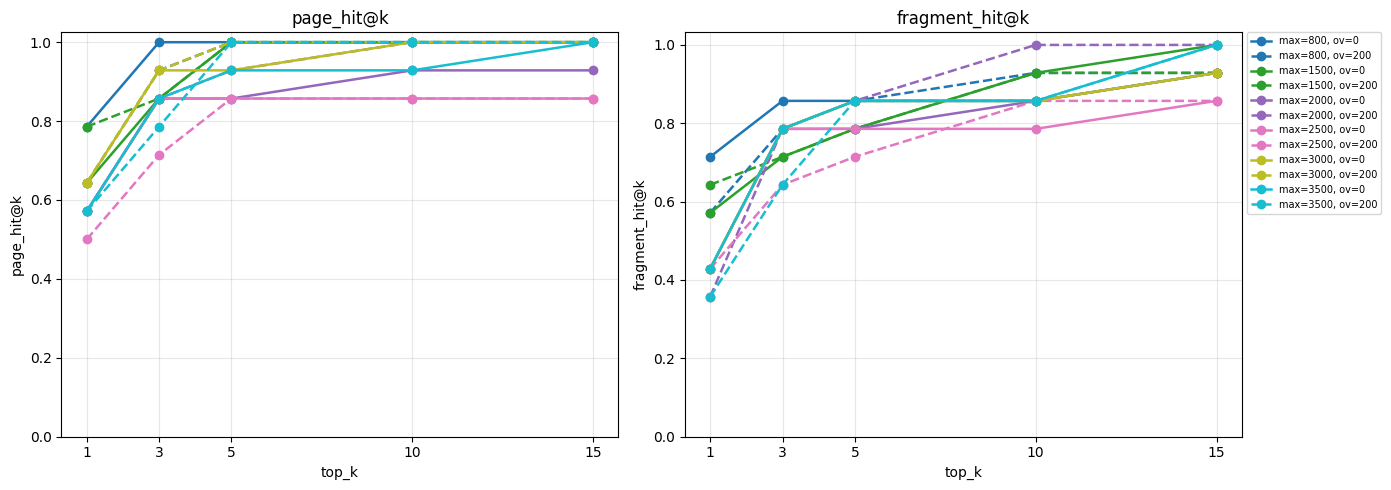

In [15]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
colors = cm.tab10(np.linspace(0, 1, len(results_df["max_chars"].unique())))
linestyles = {0: "-", 200: "--"}
color_map = {mc: c for mc, c in zip(sorted(results_df["max_chars"].unique()), colors)}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax in zip(["page_hit@k", "fragment_hit@k"], axes):
    for (mc, oc), grp in results_df.groupby(["max_chars", "overlap_chars"]):
        ax.plot(
            grp["top_k"], grp[metric],
            marker="o",
            label=f"max={mc}, ov={oc}",
            color=color_map[mc],
            linestyle=linestyles[oc],
            linewidth=1.8,
        )
    ax.set_xlabel("top_k")
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.set_xticks(TOP_K_GRID)
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)  # ← oś Y od 0

    # ax.legend(fontsize=7, ncols=2, loc="lower right")

ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
fig.tight_layout(rect=[0, 0, 0.85, 1])  # zostaw miejsce po prawej
fig.tight_layout()

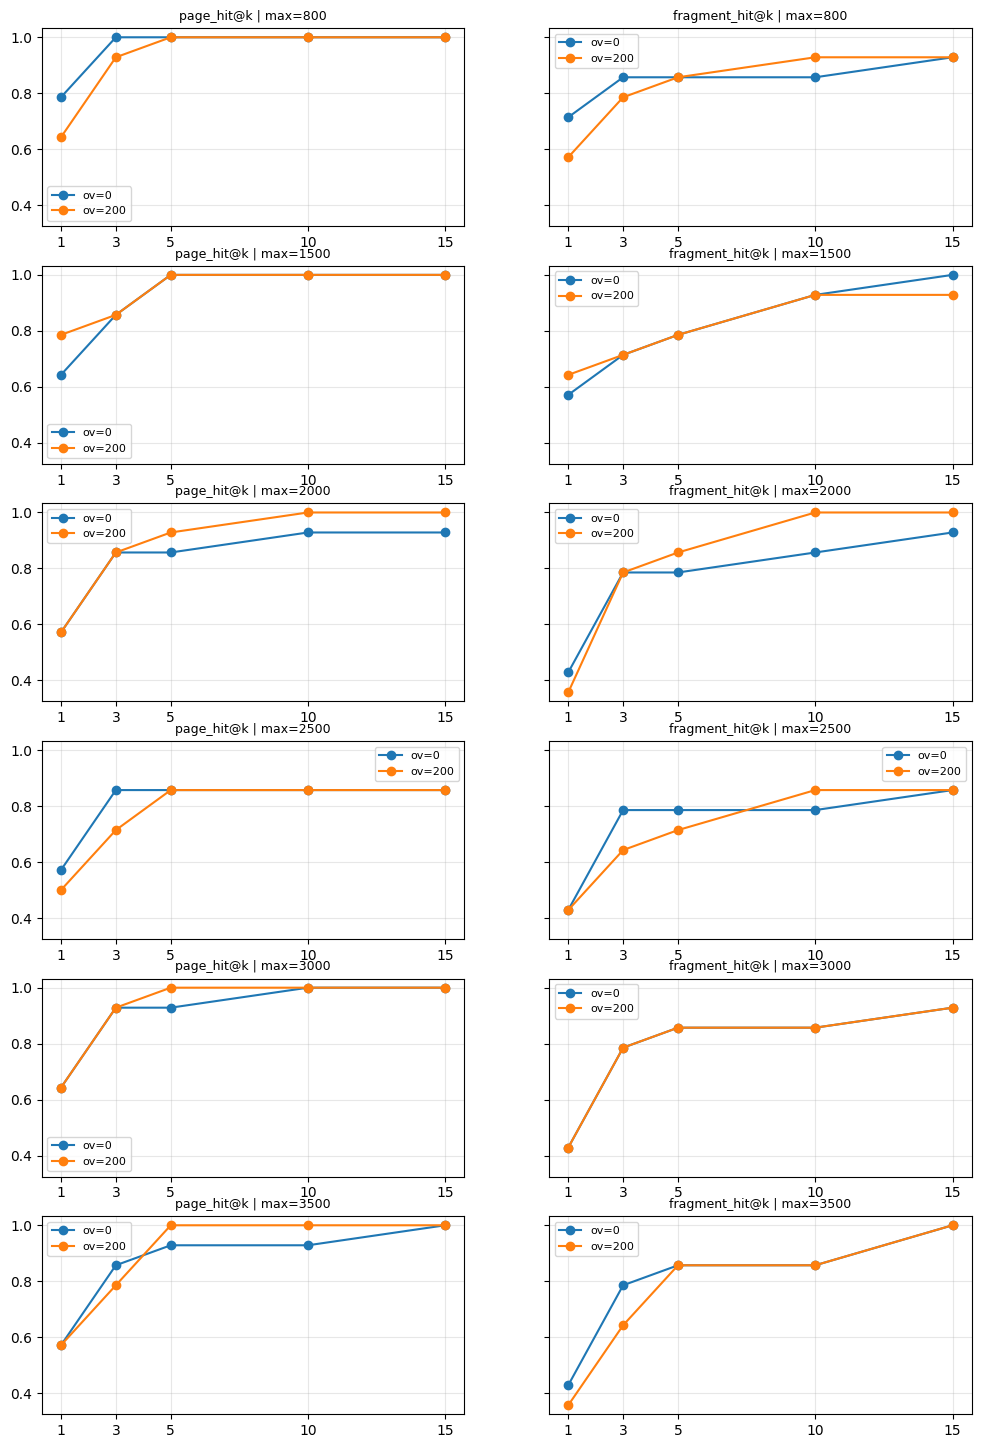

In [16]:
max_vals = sorted(results_df["max_chars"].unique())
fig, axes = plt.subplots(len(max_vals), 2, figsize=(12, 3 * len(max_vals)), sharey=True)

for i, mc in enumerate(max_vals):
    sub = results_df[results_df["max_chars"] == mc]
    for j, metric in enumerate(["page_hit@k", "fragment_hit@k"]):
        ax = axes[i, j]
        for oc, grp in sub.groupby("overlap_chars"):
            ax.plot(grp["top_k"], grp[metric], marker="o", label=f"ov={oc}")
        ax.set_title(f"{metric} | max={mc}", fontsize=9)
        ax.set_xticks(TOP_K_GRID)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

### 6.5 Sanity check — monotoniczność i relacja fragment ≤ page

In [17]:
def is_monotonic(series: pd.Series) -> bool:
    return all(a <= b for a, b in zip(series.values, series.values[1:]))


for (mc, oc), grp in results_df.sort_values("top_k").groupby(["max_chars", "overlap_chars"]):
    ph_mono = is_monotonic(grp["page_hit@k"])
    fh_mono = is_monotonic(grp["fragment_hit@k"])
    frag_le_page = (grp["fragment_hit@k"] <= grp["page_hit@k"]).all()
    print(
        f"max={mc:4d} ov={oc:3d} | page_hit monotonic: {ph_mono} | "
        f"fragment_hit monotonic: {fh_mono} | fragment<=page: {frag_le_page}"
    )

max= 800 ov=  0 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max= 800 ov=200 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max=1500 ov=  0 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max=1500 ov=200 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max=2000 ov=  0 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max=2000 ov=200 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max=2500 ov=  0 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max=2500 ov=200 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max=3000 ov=  0 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max=3000 ov=200 | page_hit monotonic: True | fragment_hit monotonic: True | fragment<=page: True
max=3500 ov=  0 | page_hit mon

## 8. (opcjonalnie) zapis wyników

In [ ]:
# results_df.to_csv(ROOT / "data" / "eval" / "chunk_size_topk_v2_openai_results.csv", index=False)
# chunk_stats_df.to_csv(ROOT / "data" / "eval" / "chunk_size_topk_v2_openai_chunk_stats.csv", index=False)

## 9. Drill-down — przegląd retrievalu per pytanie

Cel: dla każdej pary (pytanie × config) zobaczyć jakie chunki zostały zwrócone, czy trafiły w stronę GT, czy zawierają fragment GT, i który konkretnie fragment dopasowano.

`per_chunk_df` jest budowany w sekcji 5 (wspólna pętla z agregatami) — tutaj tylko go konsumujemy, bez powtórnego indeksowania i retrievalu.

In [18]:
print(f"per_chunk_df: {len(per_chunk_df)} wierszy")
per_chunk_df.head()

per_chunk_df: 2520 wierszy


,q_id,question,max_chars,overlap_chars,rank,chunk_pages,chapter,section,element_type,distance,gt_pages,page_hit_here,fragment_hit_here,matched_fragment,content_preview,content_full
0,1,Dlaczego część wsparcia BGK nie jest klasyfiko...,800,0,1,[178],X Załączniki,7. Założenia przyjęte w analizie celów SDG,text,0.360399,[7],False,0.0,None,W analizie transakcji kredytowych pod kątem ws...,W analizie transakcji kredytowych pod kątem ws...
1,1,Dlaczego część wsparcia BGK nie jest klasyfiko...,800,0,2,[7],I Jedyny taki bank,3. Podsumowanie 2024 roku,infographic,0.374699,[7],True,0.0,None,Okrągły diagram kołowy przedstawiający udział ...,Okrągły diagram kołowy przedstawiający udział ...
2,1,Dlaczego część wsparcia BGK nie jest klasyfiko...,800,0,3,[178],X Załączniki,7. Założenia przyjęte w analizie celów SDG,text,0.398232,[7],False,0.0,None,"- Przyjęto, że każda transakcja może być przyp...","- Przyjęto, że każda transakcja może być przyp..."
3,1,Dlaczego część wsparcia BGK nie jest klasyfiko...,800,0,4,[152],IX Raportowanie,"3. Indeks Celów Zrównoważonego Rozwoju ONZ, do...",table,0.398745,[7],False,0.0,None,Tabela przedstawiająca Cele Zrównoważonego Roz...,Tabela przedstawiająca Cele Zrównoważonego Roz...
4,1,Dlaczego część wsparcia BGK nie jest klasyfiko...,800,0,5,"[6, 7]",I Jedyny taki bank,3. Podsumowanie 2024 roku,text,0.402622,[7],True,0.0,None,Wygenerowane wsparcie gospodarki W 2024 r. wy...,Wygenerowane wsparcie gospodarki\n\nW 2024 r. ...


In [20]:
group_cols = ['q_id', 'max_chars']

result = (
    per_chunk_df.groupby(group_cols)
    .agg(
        # Sprawdź czy jakiekolwiek page_hit_here == 0 (wartość 0 oznacza brak trafienia)
        all_page_hit_zero=('page_hit_here', lambda x: (x == 0).all()),

        # fragment_hit_here: 0 to NaN/missing — sprawdź czy są NaN
        all_fragment_hit_missing=('fragment_hit_here', lambda x: (x == 0).all()),

        # Opcjonalnie: liczba wierszy w grupie
        count=('q_id', 'count')
    )
    .reset_index()
)
print(result)

    q_id  max_chars  all_page_hit_zero  all_fragment_hit_missing  count
0      1        800              False                      True     30
1      1       1500              False                     False     30
2      1       2000              False                     False     30
3      1       2500              False                     False     30
4      1       3000              False                     False     30
..   ...        ...                ...                       ...    ...
79    14       1500              False                     False     30
80    14       2000              False                     False     30
81    14       2500              False                     False     30
82    14       3000              False                     False     30
83    14       3500              False                     False     30

[84 rows x 5 columns]


In [ ]:
# per_chunk_df[
#     (per_chunk_df['q_id'] == 2) &
#     (per_chunk_df['max_chars'] == 1500)
# ]

### 9.1 Sanity check — spójność z `results_df` (k=5)

Agregacja `per_chunk_df` do page_hit@5 powinna zgadzać się z kolumną page_hit@k w `results_df`.

In [19]:
K_CHECK = 5
agg = (
    per_chunk_df[per_chunk_df["rank"] <= K_CHECK]
    .groupby(["max_chars", "overlap_chars", "q_id"])
    .agg(page_any=("page_hit_here", "any"), frag_any=("fragment_hit_here", "any"))
    .reset_index()
)
agg_summary = (
    agg.groupby(["max_chars", "overlap_chars"])
    .agg(page_hit=("page_any", "mean"), fragment_hit=("frag_any", "mean"))
    .reset_index()
)
expected = results_df[results_df["top_k"] == K_CHECK][["max_chars", "overlap_chars", "page_hit@k", "fragment_hit@k"]].reset_index(drop=True)
print("Z drill-down (k=5):")
print(agg_summary)
print("\nZ results_df (k=5):")
print(expected)

Z drill-down (k=5):
    max_chars  overlap_chars  page_hit  fragment_hit
0         800              0  1.000000      0.857143
1         800            200  1.000000      0.857143
2        1500              0  1.000000      0.785714
3        1500            200  1.000000      0.785714
4        2000              0  0.857143      0.785714
5        2000            200  0.928571      0.857143
6        2500              0  0.857143      0.785714
7        2500            200  0.857143      0.714286
8        3000              0  0.928571      0.857143
9        3000            200  1.000000      0.857143
10       3500              0  0.928571      0.857143
11       3500            200  1.000000      0.857143

Z results_df (k=5):
    max_chars  overlap_chars  page_hit@k  fragment_hit@k
0         800              0    1.000000        0.857143
1         800            200    1.000000        0.857143
2        1500              0    1.000000        0.785714
3        1500            200    1.000000  

### 9.2 Funkcja `show` — pretty-print retrievalu

In [24]:
def show(q_id: int, max_chars: int, overlap_chars: int, top_k: int = 5, preview_chars: int = 500) -> None:
    q = next((qq for qq in questions if qq["id"] == q_id), None)
    if q is None:
        print(f"Brak pytania o id={q_id}")
        return
    rows = per_chunk_df[
        (per_chunk_df["q_id"] == q_id)
        & (per_chunk_df["max_chars"] == max_chars)
        & (per_chunk_df["overlap_chars"] == overlap_chars)
        & (per_chunk_df["rank"] <= top_k)
    ].sort_values("rank")
    if rows.empty:
        print("Brak wierszy dla tej kombinacji — sprawdź grid.")
        return

    print("=" * 100)
    print(f"Q{q_id}: {q['question']}")
    print(f"config: max_chars={max_chars}, overlap_chars={overlap_chars}, top_k={top_k}")
    print(f"GT pages: {sorted(q['gt_pages'])}")
    print("GT fragments:")
    for f in q["gt_fragments"]:
        print(f"  - {f!r}")
    print("=" * 100)

    for _, r in rows.iterrows():
        p_mark = "✓page" if r["page_hit_here"] else "✗page"
        f_mark = "✓frag" if r["fragment_hit_here"] else "✗frag"
        header = f"{r['chapter'] or '-'} › {r['section'] or '-'}"
        print(f"\n[{r['rank']}] {p_mark} {f_mark}  pages={r['chunk_pages']}  type={r['element_type']}  dist={r['distance']:.3f}")
        print(f"    {header}")
        if r["fragment_hit_here"]:
            print(f"    matched_fragment: {r['matched_fragment']!r}")
        content = r["content_full"]
        if len(content) > preview_chars:
            content = content[:preview_chars] + " …"
        for line in content.splitlines():
            print(f"    {line}")

### 9.3 Anomalie — `fragment_hit=True & page_hit=False`

Wyszukujemy pary (pytanie × config), gdzie retrieval „dopasował" fragment treściowo, ale żaden ze zwróconych chunków nie trafia w strony GT. To przypadki, które złamały sanity check `fragment ≤ page`.

In [25]:
anomaly = (
    per_chunk_df.groupby(["q_id", "max_chars", "overlap_chars"])
    .agg(page_any=("page_hit_here", "any"), frag_any=("fragment_hit_here", "any"))
    .query("frag_any and not page_any")
    .reset_index()
)
print(f"Anomalii: {len(anomaly)}")
anomaly

Anomalii: 0


,q_id,max_chars,overlap_chars,page_any,frag_any


In [26]:
if not anomaly.empty:
    row = anomaly.iloc[0]
    show(q_id=int(row["q_id"]), max_chars=int(row["max_chars"]), overlap_chars=int(row["overlap_chars"]), top_k=5)
else:
    print("Brak anomalii — sanity check przeszedł dla wszystkich configów.")

Brak anomalii — sanity check przeszedł dla wszystkich configów.


### 9.4 Ręczny sandbox

In [28]:
show(q_id=2, max_chars=800, overlap_chars=200, top_k=10, preview_chars=99999)

Q2: Kto został powołany na prezesa Zarządu BGK w 2024 roku?
config: max_chars=800, overlap_chars=200, top_k=10
GT pages: [9, 112]
GT fragments:
  - 'Mirosław Czekaj został powołany na prezesa Zarządu BGK.'
  - 'Tabela 63. Skład Zarządu BGK'

[1] ✓page ✗frag  pages=[112]  type=text  dist=0.215
    VI Ład korporacyjny › 4. Zasady, zadania i zakres działania organów i komitetów
    W 2024 r. Zarząd BGK odbył 55 posiedzeń i podjął 388 uchwał.
    
    Zmiany w składzie Zarządu w 2024 r.:
    
    - Prezes Rady Ministrów odwołał: z dniem 11 stycznia 2024 r. Beatę Daszyńską-Muzyczkę ze stanowiska prezesa Zarządu BGK; z dniem 11 kwietnia 2024 r. Pawła Nieradę ze stanowiska pierwszego wiceprezesa Zarządu; z dniem 12 kwietnia 2024 r. Marka Tomczuka ze stanowiska członka Zarządu; z dniem 27 czerwca 2024 r. Radosława Kwietnia ze stanowiska członka Zarządu; z dniem 2 lipca 2024 r. Tomasza Robaczyńskiego ze stanowiska członka Zarządu;
    - Prezes Rady Ministrów powołał z dniem 12 kwietnia 2024 r. 

## 10. Rekomendacja defaultów

Wybór zwycięskiej pary `(max_chars, overlap_chars)` dla `k_primary = 5`. Kryteria (w tej kolejności):
1. `page_hit@5` desc
2. `fragment_hit@5` desc
3. `max_chars` asc (mniejsze chunki — większa precyzja, mniejszy koszt kontekstu)
4. `overlap_chars` asc (mniej duplikacji w indeksie)

In [21]:
K_PRIMARY = 5

ranking = (
    results_df[results_df["top_k"] == K_PRIMARY]
    .copy()
    .sort_values(
        by=["page_hit@k", "fragment_hit@k", "max_chars", "overlap_chars"],
        ascending=[False, False, True, True],
    )
    .reset_index(drop=True)
)
ranking

,max_chars,overlap_chars,top_k,page_hit@k,fragment_hit@k,page_hits,fragment_hits,n_questions
0,800,0,5,1.000000,0.857143,14,12,14
1,800,200,5,1.000000,0.857143,14,12,14
2,3000,200,5,1.000000,0.857143,14,12,14
3,3500,200,5,1.000000,0.857143,14,12,14
4,1500,0,5,1.000000,0.785714,14,11,14
5,1500,200,5,1.000000,0.785714,14,11,14
6,2000,200,5,0.928571,0.857143,13,12,14
7,3000,0,5,0.928571,0.857143,13,12,14
8,3500,0,5,0.928571,0.857143,13,12,14
9,2000,0,5,0.857143,0.785714,12,11,14


In [22]:
best = ranking.iloc[0]
rec_max_chars = int(best["max_chars"])
rec_overlap = int(best["overlap_chars"])
rec_top_k = K_PRIMARY

print("Rekomendacja:")
print(f"  VISION_CHUNK_MAX_CHARS    = {rec_max_chars}")
print(f"  VISION_CHUNK_OVERLAP_CHARS = {rec_overlap}")
print(f"  TOP_K                      = {rec_top_k}")
print(f"  -> page_hit@{K_PRIMARY} = {best['page_hit@k']:.3f}, fragment_hit@{K_PRIMARY} = {best['fragment_hit@k']:.3f}")
print()
print("Sugerowany diff do backend/app/config.py (nie stosowany automatycznie):")
print("---")
print(f"VISION_CHUNK_MAX_CHARS = {rec_max_chars}")
print(f"VISION_CHUNK_OVERLAP_CHARS = {rec_overlap}")
print(f"TOP_K = {rec_top_k}")
print("---")

Rekomendacja:
  VISION_CHUNK_MAX_CHARS    = 800
  VISION_CHUNK_OVERLAP_CHARS = 0
  TOP_K                      = 5
  -> page_hit@5 = 1.000, fragment_hit@5 = 0.857

Sugerowany diff do backend/app/config.py (nie stosowany automatycznie):
---
VISION_CHUNK_MAX_CHARS = 800
VISION_CHUNK_OVERLAP_CHARS = 0
TOP_K = 5
---
